# 📊 Introduction

Customer churn is a major challenge in the telecommunications industry. Companies need to understand why customers leave and how to prevent it.

In this project, we analyze the Telco Customer Churn dataset to identify patterns and factors that influence customer churn. We also build machine learning models to predict whether a customer will churn or not.

The goal of this project is not only to build a predictive model but also to generate meaningful business insights that can help improve customer retention strategies.

# DATA UNDERSTANDING

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print("=== HEAD DATA ===")
print(df.head())

=== HEAD DATA ===
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


DISTRIBUSI CHURN

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


# DATA CLEANING

UBAH TOTAL CHARGE DARI TIPE DATA OBJECT KE INTEGER

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

HANDLE MISSING VALUE

In [ ]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
11


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_3273/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# EXPLORATORY DATA ANALYSIS

CHURN VS MONTHLY CHARGES
-->APAKAH CHURN DI SEBABKAN OLEH BIAYA TINGGI?

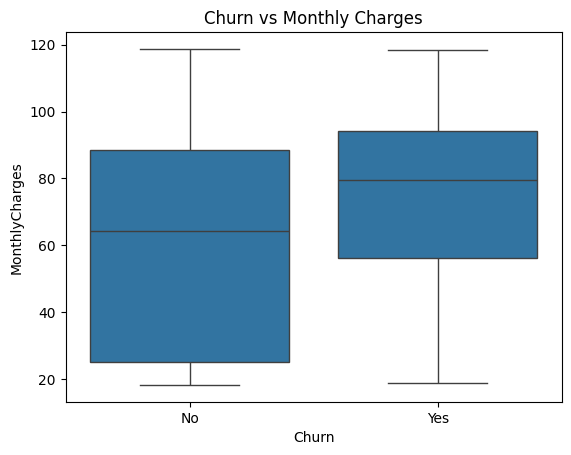

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

CHURN VS TECH SUPPORT
--> APAKAH CHURN KARENA KURANGNYA TECH SUPPORT?

In [ ]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


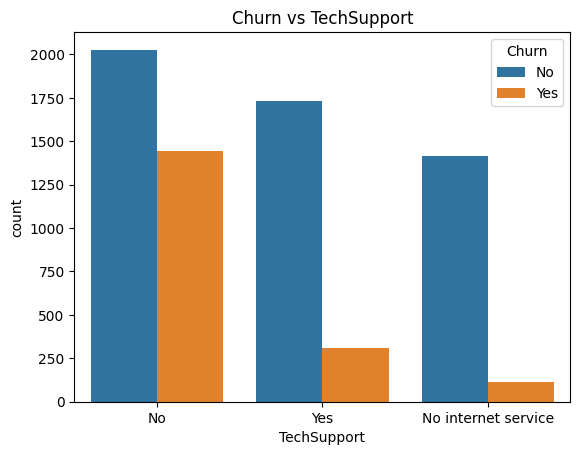

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Churn vs TechSupport")
plt.show()

# FEATURE ENGINEERING

TENURE GROUP

In [ ]:
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['New', 'Mid', 'Loyal', 'Very Loyal'])

AVG SPEND

In [ ]:
df['avg_spend'] = df['TotalCharges'] / df['tenure']

In [ ]:
df['avg_spend'] = df.apply(
    lambda x: x['TotalCharges']/x['tenure'] if x['tenure'] > 0 else 0,
    axis=1
)

NUM SERVICES

In [ ]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in services:
    df[col] = df[col].replace({'No internet service': 'No'})

df['num_services'] = (df[services] == 'Yes').sum(axis=1)

In [ ]:
df['high_charges'] = df['MonthlyCharges'].apply(lambda x: 1 if x > 70 else 0)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# MODELING

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# EVALUASI

In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1036
           1       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.69      0.46      0.55       373

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

LR Accuracy: 0.8112136266855926
RF Accuracy: 0.8019872249822569


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

                             feature  importance
3                       TotalCharges    0.086576
1                             tenure    0.079292
4                          avg_spend    0.072402
2                     MonthlyCharges    0.071975
5                       num_services    0.028524
7067  PaymentMethod_Electronic check    0.026982
7055     InternetService_Fiber optic    0.026321
7064               Contract_Two year    0.019840
7071         tenure_group_Very Loyal    0.018091
7065            PaperlessBilling_Yes    0.017705


# 📌 Conclusion & Business Insight

Based on the exploratory data analysis and machine learning modeling, several important insights were identified regarding customer churn behavior.

From the analysis, it was found that customers with higher monthly charges tend to have a higher likelihood of churning. This indicates that pricing plays a significant role in customer retention. In addition, customers who do not use Tech Support services show a significantly higher churn rate, suggesting that customer support is a key factor in maintaining customer loyalty.

In the modeling phase, two models were evaluated: Logistic Regression and Random Forest. Logistic Regression achieved better performance in detecting churn with a recall score of 0.58, compared to 0.46 from Random Forest. Since the primary objective is to identify as many potential churn customers as possible, Logistic Regression is considered the more suitable model for this case.

# 💡 Business Recommendations
Based on these findings, the company can take the following actions:
- Adjust pricing strategies, especially for customers with high monthly charges
- Improve and promote Tech Support services to increase customer satisfaction
- Implement targeted retention strategies for high-risk customers

Overall, this project demonstrates how data-driven approaches can help businesses better understand customer behavior and reduce churn through strategic decision-making.

This project highlights the importance of combining data analysis and business understanding to generate actionable insights.